In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ROOT
import seaborn as sns
from functions import *

Welcome to JupyROOT 6.30/08


In [2]:
dest_dir = "/u/yanwang/Documents/pictures/DPG2025"

In [3]:
hist_filename = "/lustre/r3b/ywang/exp202402/prebeam/millepede2/cal.root"
hist_file = ROOT.TFile(hist_filename, "read")
hist_folder = hist_file.GetDirectory("HistMonitor/NeulandCal2HitParTask")
hist_time_offsets = hist_folder.Get("hist_time_offsets;1")
data_x, data_y, data_z = convert_2d_to_arrays(hist_time_offsets)

Warning in <TClass::Init>: no dictionary for class pair<int,R3B::Neuland::PlaneCalData> is available
Warning in <TClass::Init>: no dictionary for class R3B::Neuland::PlaneCalData is available
Warning in <TClass::Init>: no dictionary for class pair<int,R3B::Neuland::BarCalData> is available
Warning in <TStreamerInfo::BuildCheck>: 
   The StreamerInfo of class R3B::Neuland::BarCalData read from file /lustre/r3b/ywang/exp202402/prebeam/millepede2/cal.root
   has the same version (=1) as the active class but a different checksum.
   You should update the version to ClassDef(R3B::Neuland::BarCalData,2).
   Do not try to write objects with the current class definition,
   the files will not be readable.

Warning in <TStreamerInfo::CompareContent>: The following data member of
the on-file layout version 1 of class 'R3B::Neuland::BarCalData' differs from 
the in-memory layout version 1:
   int module_num; //
vs
   unsigned int module_num; //


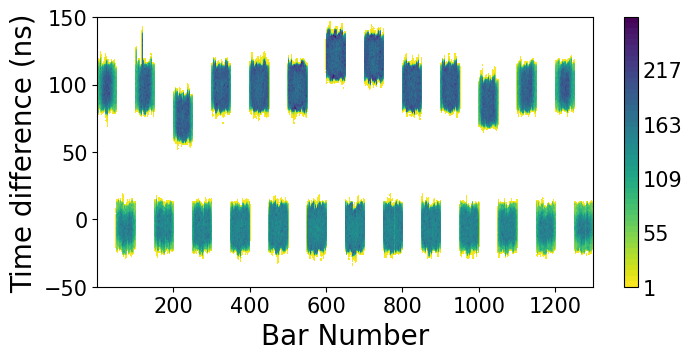

In [4]:
fig, ax = plt.subplots()
plot = ax.contourf(
    data_x, data_y, data_z, cmap="viridis_r", levels=np.linspace(1, np.amax(data_z), 50)
)
ax.set_ylim(-50, 150)
ax.set_xlabel("Bar Number", fontsize=20)
ax.set_ylabel("Time difference (ns)", fontsize=20)
ax.tick_params(labelsize=15)
fig.set_size_inches(8, 3.5)
cbar = fig.colorbar(plot, ticks=np.linspace(1, 271, 6))
cbar.ax.tick_params(size=0, labelsize=15)

# fig.subplots_adjust(bottom = 0.1)
fig.savefig(fname=f"{dest_dir}/TimeDiffDist", bbox_inches="tight", dpi = 300)

In [5]:
hist_proj = hist_time_offsets.ProjectionY("_py", 230, 230)
res = np.zeros(2)
quantiles = np.array([0.1, 0.9])
hist_proj.GetQuantiles(2, res, quantiles)
print(f"lower: {res[0]}, higher: {res[1]}")

lower: 62.39631901840491, higher: 86.94111111111111


In [7]:
data = convert_to_df(hist_proj)
x_range = [50, 100]

In [9]:
def plot_data(step, is_save=False):
    ax = sns.lineplot(data, x="x", y="y", drawstyle="steps")
    ax.set(xlabel="Time difference (ns)", ylabel="counts")
    ax.set_xlim(x_range[0], x_range[1])

    ax2 = plt.twinx()
    sns.scatterplot(data, x="x", y="CDF", ax=ax2, color="g", marker=".")
    ax2.set_ylabel("CDF", fontsize=20)
    ax2.tick_params(labelsize=15)
    if step >= 1:
        plt.axvline(x=res[0], color="grey", linestyle="--")
        plt.axvline(x=res[1], color="grey", linestyle="--")

    if step >= 2:
        fit_data = data[data["x"] > res[0]]
        fit_data = fit_data[fit_data["x"] < res[1]]
        sns.regplot(
            fit_data, x="x", y="CDF", ax=ax2, marker=".", line_kws=dict(color="r")
        )

    ax.set_xlabel("Time difference (ns)", fontsize=20)
    ax.set_ylabel("counts per 1 ns", fontsize=20)
    ax.tick_params(labelsize=15)
    if is_save:
        plt.savefig(f"{dest_dir}/TimeDifference_{step}.png", bbox_inches="tight", dpi = 300)
        print(f"Saving picture to {dest_dir}/TimeDifference_{step}.png")
    plt.show()

Saving picture to /u/yanwang/Documents/pictures/DPG2025/TimeDifference_0.png


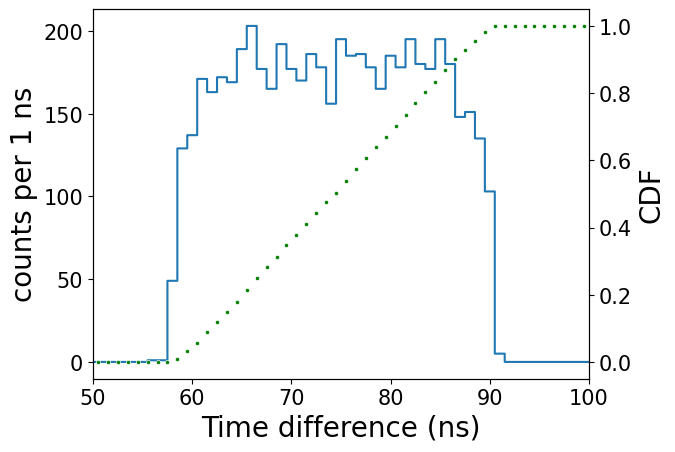

Saving picture to /u/yanwang/Documents/pictures/DPG2025/TimeDifference_1.png


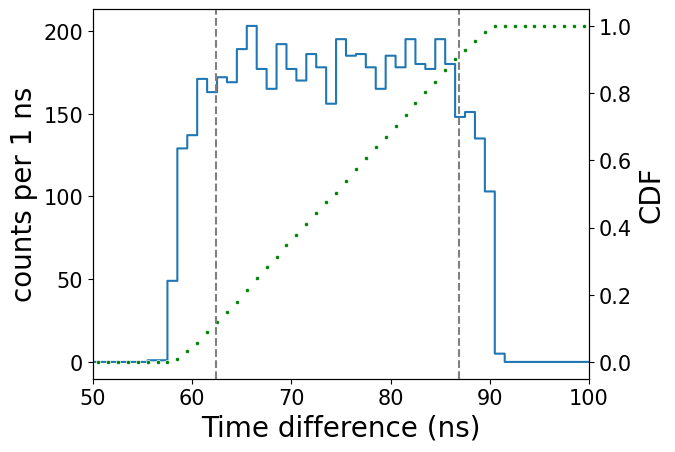

Saving picture to /u/yanwang/Documents/pictures/DPG2025/TimeDifference_2.png


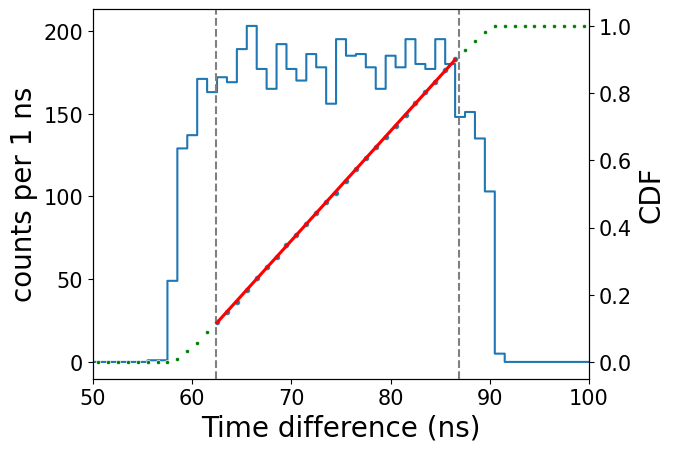

In [10]:
for step in range(0, 3):
    plot_data(step, True)